In [1]:
import os

import dotenv
import regex as re
import matplotlib.pyplot as plt
from llama_index.llms.ollama import Ollama
from llama_index.multi_modal_llms.ollama import OllamaMultiModal
from llama_index.multi_modal_llms.openai import OpenAIMultiModal
from llama_index.core.multi_modal_llms.generic_utils import load_image_urls
from llama_index.core.llms import ChatMessage, MessageRole, ImageBlock
from llama_index.core.schema import Document, MediaResource, ImageDocument
from llama_index.llms.openai_like import OpenAILike
from llama_index.multi_modal_llms.openai.utils import (
    generate_openai_multi_modal_chat_message, )
from IPython.display import Markdown, display
from transformers import AutoModelForCausalLM, AutoTokenizer

dotenv.load_dotenv()

d:\Program\miniconda3\envs\llama-index\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [34]:
# Silicon Flow
qwen_vl2 = OpenAILike(
    model="Qwen/Qwen2-VL-72B-Instruct",
    api_base=os.environ.get("SILICONFLOW_API_BASE"),
    api_key=os.environ.get("SILICONFLOW_API_KEY"),
    is_chat_model=True,
    is_function_calling_model=True,
)

In [2]:
# Qwen
qwen_vl2 = OpenAILike(
    model="qwen-vl-max",
    api_base=os.environ.get("QWEN_API_BASE"),
    api_key=os.environ.get("QWEN_API_KEY"),
    is_chat_model=True,
    is_function_calling_model=True,
)

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen-VL-Chat",
                                          trust_remote_code=True)

In [3]:
# Qwen
image_path = "../images/start.png"
chat_msg_1 = generate_openai_multi_modal_chat_message(
    prompt="框出图中zoom的位置",
    role="user",
    image_documents=[ImageDocument(image_path=image_path)],
)
response = qwen_vl2.chat([chat_msg_1])
display(Markdown(f"<b>{response.message.content}</b>"))

<b><|object_ref_start|>Zoom<|object_ref_end|><|box_start|>(381,507),(426,593)<|box_end|></b>

In [5]:
text = re.sub(r'object_|\||_start', '', response.message.content)
text = re.sub(r"([a-z]+?)_end", r"/\1", text)
text

'<ref>Zoom</ref><box>(375,508),(421,596)</box>'

In [6]:
history = [
    {
        'image': image_path
    },  # Either a local path or an url
    {
        'text': "框出图中zoom的位置"
    },
]
temp = tokenizer.from_list_format(history)
# tokenizer.to_list_format(temp)

In [18]:
image = tokenizer.draw_bbox_on_latest_picture(text, [(temp, None)])

In [8]:
image.save("output.png")

In [9]:
from PIL import Image, ImageDraw

In [14]:
img = Image.open(image_path)
draw = ImageDraw.ImageDraw(img)
draw.rectangle(((375, 508), (421, 596)), outline="red", width=2)


In [16]:
img.size

(2160, 1440)

In [15]:
img.save("output2.png")

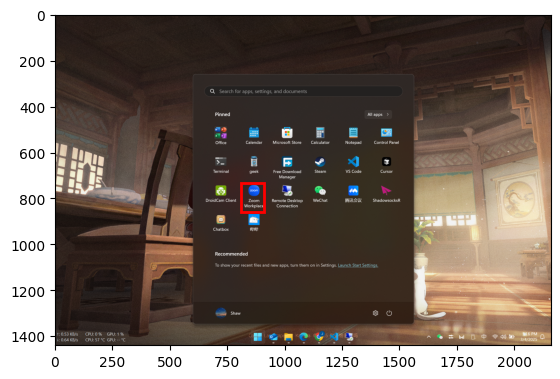

In [21]:
import matplotlib.patches as patches

img = plt.imread(image_path)
# plt.imshow(img)
# plt.gca().add_patch(pat.Rectangle((205, 72), 170, 147, linewidth=2, edgecolor='r', facecolor='None'))
fig, ax = plt.subplots(1)
ax.imshow(img)
# Rectangle 坐标的参数格式为左上角（x, y），width, height。
(x1, y1), (x2, y2) = (375, 508), (421, 596)
w, h = img.shape[1], img.shape[0]
x1, y1, x2, y2 = (int(x1 / 1000 * w), int(y1 / 1000 * h), int(x2 / 1000 * w),
                  int(y2 / 1000 * h))
rec = patches.Rectangle((x1, y1),
                        x2 - x1,
                        y2 - y1,
                        linewidth=2,
                        edgecolor='r',
                        facecolor='None')
ax.add_patch(rec)
plt.imshow(img)
plt.show()
# fig.savefig('new_test_1.jpg')

## Ollama

In [ ]:
llm = OllamaMultiModal(model="minicpm-v", request_timeout=300.0)

In [ ]:
msg = ChatMessage(
    role=MessageRole.USER,
    content="描述图片",
    additional_kwargs={"images": [ImageDocument(image_path="2.jpg")]})
response = llm.chat([msg])
display(Markdown(f"<b>{response.message.content}</b>"))

<b>这幅图片展示了一个动漫风格的年轻角色，她盘腿坐在一个树干上。这个人物有着长长的金色头发，头上戴着类似鹿角的装饰物，并穿着一件蓝色和绿色调相间的服装，有蝴蝶结装饰。她的眼睛是绿色的，表情充满了沉思或满足感，手托着下巴。周围环境暗示了一个郁绿葱翠、阳光透过树叶照射下来的森林场景。树皮纹理细致逼真，叶子呈现出各种绿色调以及一丝紫色的色调，为图片增添了活力和动感。这幅画采用了数字艺术风格，有着明显的刷子笔触和光影效果使它看起来栩栩如生，并且具有梦幻般的质感。</b>

In [ ]:
image_urls = [
    # "https://www.visualcapitalist.com/wp-content/uploads/2023/10/US_Mortgage_Rate_Surge-Sept-11-1.jpg",
    # "https://www.sportsnet.ca/wp-content/uploads/2023/11/CP1688996471-1040x572.jpg",
    "https://sf-maas-uat-prod.oss-cn-shanghai.aliyuncs.com/dog.png",
    # "https://www.cleverfiles.com/howto/wp-content/uploads/2018/03/minion.jpg",
]
image_documents = load_image_urls(image_urls)

In [14]:
images = [each.image for each in msg.blocks if isinstance(each, ImageBlock)]
images
# images = [
#     each.image for each in message.blocks
#     if isinstance(each, ImageBlock)
# ]

[b'...']